# Notebook 01 — Data Exploration

Before training any model, we need to understand what we're working with.
This notebook answers four questions:
1. How balanced are the classes?
2. What do the images actually look like?
3. Are there significant resolution differences across the dataset?
4. What are the per-channel pixel statistics (needed to choose normalisation constants)?

**Dataset:** Kermany 2018 OCT2017  
**Classes:** CNV · DME · DRUSEN · NORMAL  

In [1]:
import os
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from PIL import Image
import random

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

DATA_DIR = Path('../data')
TRAIN_DIR = DATA_DIR / 'train'
TEST_DIR  = DATA_DIR / 'test'
CLASS_NAMES = ['CNV', 'DME', 'DRUSEN', 'NORMAL']
CLASS_COLORS = ['#e63946', '#457b9d', '#2a9d8f', '#264653']
random.seed(42)

## 1. Class Distribution


Training set class distribution:
  CNV         37205  (44.6%)
  DME         11348  (13.6%)
  DRUSEN       8616  (10.3%)
  NORMAL      26315  (31.5%)
  TOTAL       83484


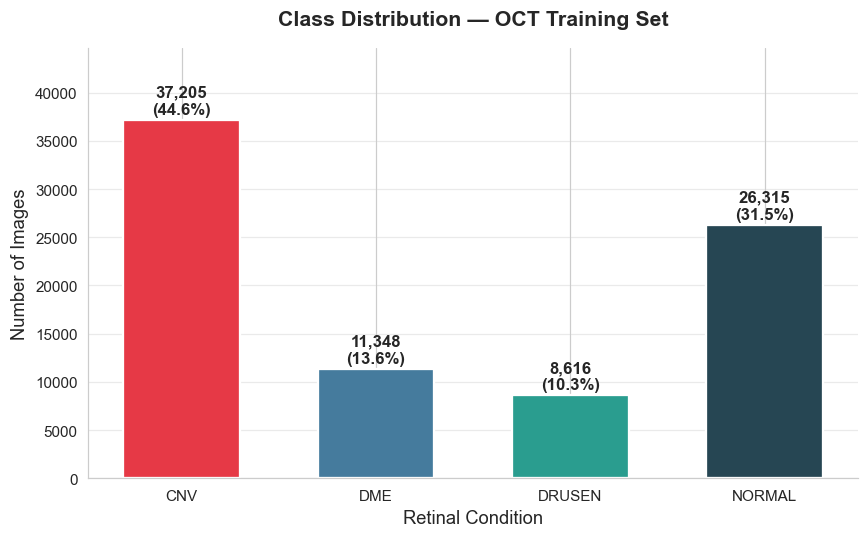


Note: CNV and NORMAL dominate; DRUSEN is significantly under-represented.
This imbalance may hurt DRUSEN recall — consider class-weighted loss in production.


In [2]:
# Count files in each class
class_counts = {}
for cls in CLASS_NAMES:
    cls_dir = TRAIN_DIR / cls
    class_counts[cls] = len(list(cls_dir.glob('*.jpeg')) + list(cls_dir.glob('*.jpg')))

total = sum(class_counts.values())
print('\nTraining set class distribution:')
for cls, n in class_counts.items():
    print(f'  {cls:<10} {n:>6}  ({100*n/total:.1f}%)')
print(f'  {"TOTAL":<10} {total:>6}')

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(class_counts.keys(), class_counts.values(), color=CLASS_COLORS, width=0.6, edgecolor='white', linewidth=1.5)
for bar, (cls, n) in zip(bars, class_counts.items()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{n:,}\n({100*n/total:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Class Distribution — OCT Training Set', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_xlabel('Retinal Condition', fontsize=12)
ax.set_ylim(0, max(class_counts.values()) * 1.2)
ax.grid(axis='y', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.savefig('../results/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nNote: CNV and NORMAL dominate; DRUSEN is significantly under-represented.')
print('This imbalance may hurt DRUSEN recall — consider class-weighted loss in production.')

## 2. Sample Images Grid (4 classes × 5 images)

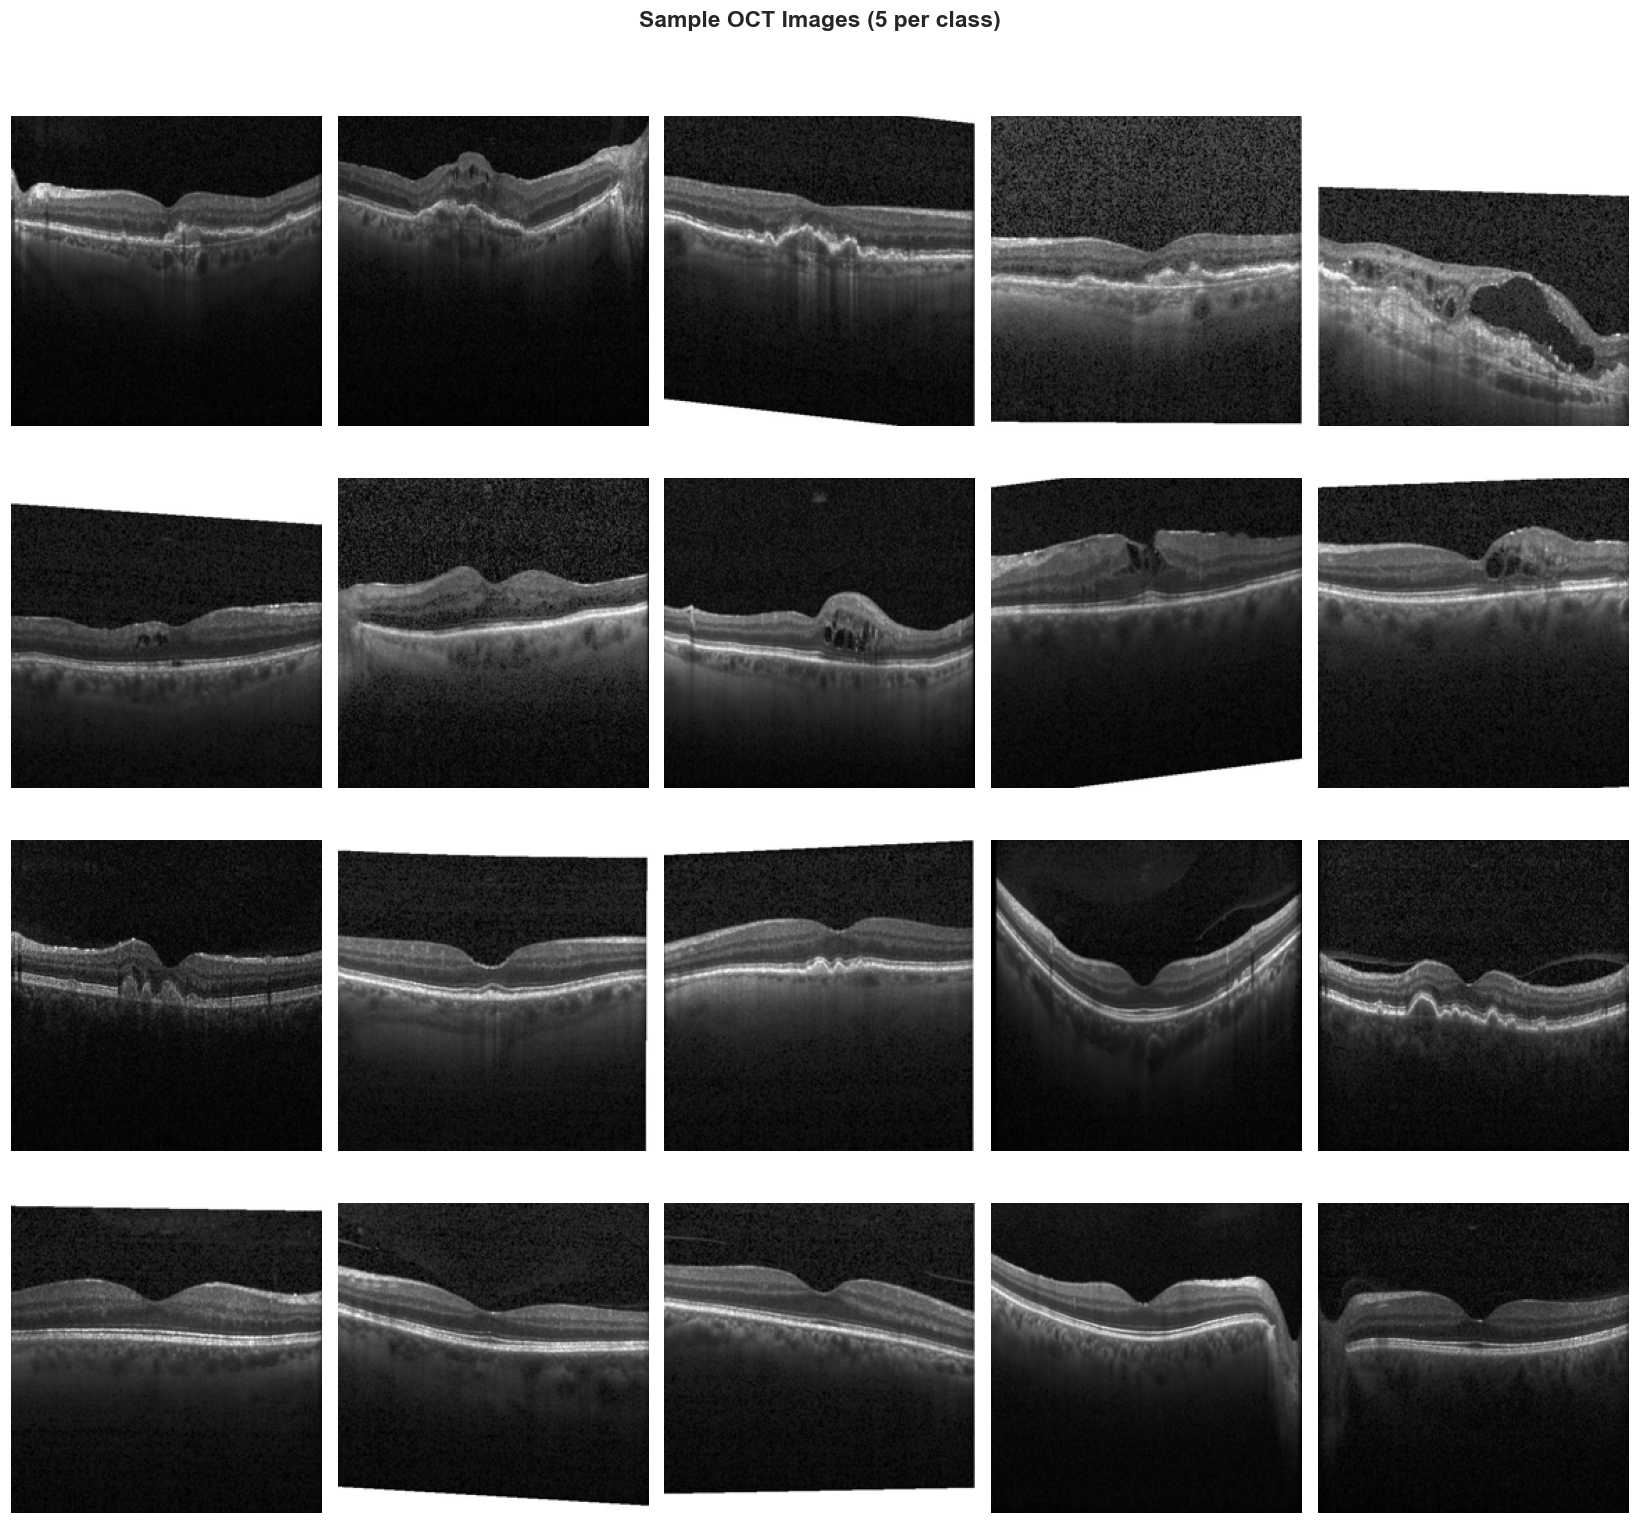

In [3]:
N_PER_CLASS = 5
fig, axes = plt.subplots(4, N_PER_CLASS, figsize=(N_PER_CLASS * 3, 14))
fig.suptitle('Sample OCT Images (5 per class)', fontsize=15, fontweight='bold', y=1.01)

class_descriptions = {
    'CNV':    'Choroidal Neovascularisation\n(subretinal membrane + fluid)',
    'DME':    'Diabetic Macular Edema\n(intraretinal fluid pockets)',
    'DRUSEN': 'Early AMD Drusen\n(bumpy RPE, deposits)',
    'NORMAL': 'Healthy Retina\n(smooth foveal pit, intact layers)',
}

for row, (cls, color) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
    cls_dir = TRAIN_DIR / cls
    images  = random.sample(list(cls_dir.glob('*.jpeg')), N_PER_CLASS)
    for col, img_path in enumerate(images):
        img = Image.open(img_path).convert('RGB').resize((224, 224))
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].axis('off')
        # Coloured border
        for spine in axes[row, col].spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)
            spine.set_visible(True)
    # Class label on leftmost image
    axes[row, 0].set_ylabel(
        class_descriptions[cls], fontsize=10, color=color, fontweight='bold',
        rotation=0, ha='right', va='center', labelpad=5
    )

plt.tight_layout()
plt.savefig('../results/sample_images_grid.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Image Resolution Distribution

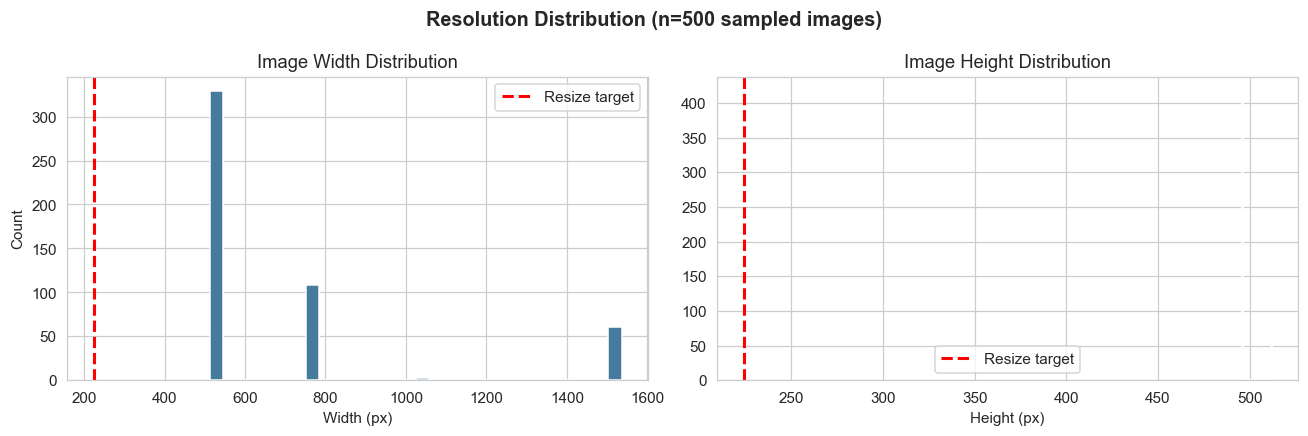

Width  — mean: 694px  std: 332px
Height — mean: 499px  std: 6px


In [4]:
widths, heights = [], []
# Sample 500 random images (full scan is slow)
all_imgs = list(TRAIN_DIR.rglob('*.jpeg'))
sample   = random.sample(all_imgs, min(500, len(all_imgs)))

for p in sample:
    with Image.open(p) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(widths,  bins=30, color='#457b9d', edgecolor='white')
ax1.axvline(224, color='red', linewidth=2, linestyle='--', label='Resize target')
ax1.set_title('Image Width Distribution', fontsize=12)
ax1.set_xlabel('Width (px)'); ax1.set_ylabel('Count'); ax1.legend()

ax2.hist(heights, bins=30, color='#2a9d8f', edgecolor='white')
ax2.axvline(224, color='red', linewidth=2, linestyle='--', label='Resize target')
ax2.set_title('Image Height Distribution', fontsize=12)
ax2.set_xlabel('Height (px)'); ax2.legend()

plt.suptitle(f'Resolution Distribution (n={len(sample)} sampled images)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/resolution_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Width  — mean: {np.mean(widths):.0f}px  std: {np.std(widths):.0f}px')
print(f'Height — mean: {np.mean(heights):.0f}px  std: {np.std(heights):.0f}px')

## 4. Per-Channel Pixel Statistics

We compute mean and standard deviation per RGB channel across the sampled images.
These values justify our choice of **ImageNet normalisation constants** (mean ≈ 0.45, std ≈ 0.22), 
which are close enough to OCT statistics to be a valid starting point for training from scratch.

Per-channel statistics (computed from 200 sampled training images):
  Channel 0 (RGB[0])  mean=0.2077  std=0.2080
  Channel 1 (RGB[1])  mean=0.2077  std=0.2080
  Channel 2 (RGB[2])  mean=0.2077  std=0.2080

ImageNet constants we use:
  mean = [0.485, 0.456, 0.406]
  std  = [0.229, 0.224, 0.225]

OCT images are near-grayscale (R≈G≈B), so channel means are similar.
The small difference from ImageNet is negligible for training-from-scratch scenarios.


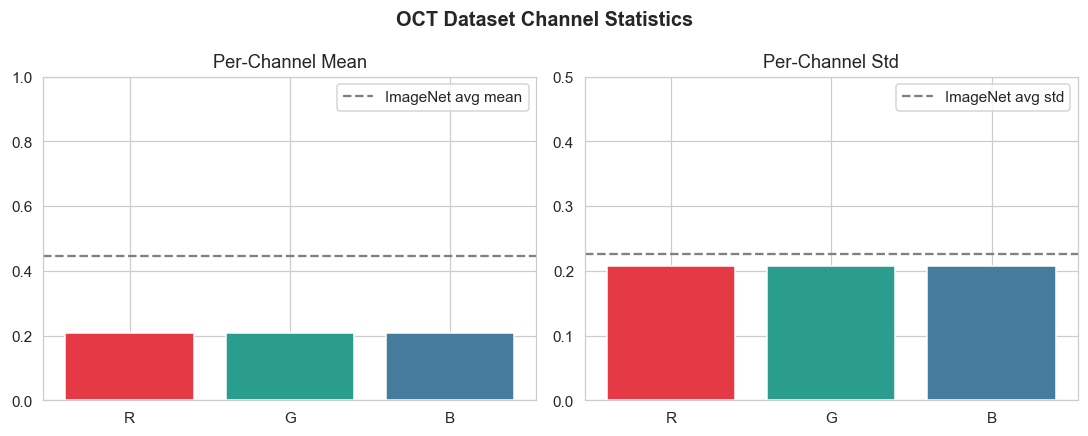

In [5]:
import torch
import torchvision.transforms.functional as TF

channel_means = torch.zeros(3)
channel_stds  = torch.zeros(3)
n = 0

for p in sample[:200]:   # cap at 200 for speed
    img = Image.open(p).convert('RGB').resize((224, 224))
    t   = TF.to_tensor(img)   # [3, H, W] in [0, 1]
    channel_means += t.mean(dim=(1, 2))
    channel_stds  += t.std(dim=(1, 2))
    n += 1

channel_means /= n
channel_stds  /= n

print('Per-channel statistics (computed from 200 sampled training images):')
for ch, (m, s) in enumerate(zip(channel_means, channel_stds)):
    print(f'  Channel {ch} (RGB[{ch}])  mean={m:.4f}  std={s:.4f}')
print()
print('ImageNet constants we use:')
print('  mean = [0.485, 0.456, 0.406]')
print('  std  = [0.229, 0.224, 0.225]')
print()
print('OCT images are near-grayscale (R≈G≈B), so channel means are similar.')
print('The small difference from ImageNet is negligible for training-from-scratch scenarios.')

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ch_names  = ['R', 'G', 'B']
ch_colors = ['#e63946', '#2a9d8f', '#457b9d']

axes[0].bar(ch_names, channel_means.numpy(), color=ch_colors, edgecolor='white')
axes[0].axhline(0.445, linestyle='--', color='gray', label='ImageNet avg mean')
axes[0].set_title('Per-Channel Mean'); axes[0].set_ylim(0, 1); axes[0].legend()

axes[1].bar(ch_names, channel_stds.numpy(), color=ch_colors, edgecolor='white')
axes[1].axhline(0.226, linestyle='--', color='gray', label='ImageNet avg std')
axes[1].set_title('Per-Channel Std'); axes[1].set_ylim(0, 0.5); axes[1].legend()

plt.suptitle('OCT Dataset Channel Statistics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/channel_stats.png', dpi=150, bbox_inches='tight')
plt.show()